In [1]:
%matplotlib widget
import os
import re
from collections import defaultdict
from pathlib import Path
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. STYLE CONFIGURATION
# ============================================================

poster_style = {
    "figsize": (4, 4),
    "dpi": 150,
    "font_size": 10,
    "title_size": 12,
    "label_size": 12,
    "legend_size": 8,
    "line_width": 1.5,
    "font_family": "Calibri",
    "grid": False,               
    "colors": ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00", "#F0E442"], 
    "linestyles": ["-", "-", "-", "-"]
}

# ============================================================
# 2. LOAD RAMAN TXT SPECTRA & GROUP THEM
# ============================================================

target_dirs = [
    r"H:\FUBerlin\Measurements\Raman Xplora\CristianB\20260218_Ram_CNT_dispersions",
    r"H:\FUBerlin\Measurements\Raman Xplora\CristianB\20260220_Ram_CNT_dispersions",
    r"H:\FUBerlin\Measurements\Raman Xplora\CristianB\20260313_Ram_CNT_DGU_fractions",
    r"H:\FUBerlin\Measurements\Raman Xplora\CristianB\20260402_CNT_F005_6FBz@P2",
    r"H:\FUBerlin\Measurements\Raman Xplora\CristianB\20260529_CNT_F005_6FBz@P2_phDADQ_6FBz_P2Ref@P2",
    r"H:\FUBerlin\Measurements\Raman Xplora\CristianB\20260605_CNT_F005_6FBz@P2_F006_phDADQ@P2",
    r"H:\FUBerlin\Measurements\Raman Xplora\CristianB\20260807_FilledCNTs_PostDGU_P2_F005LP_F006WA_F007WA",
]

raman_spectra = {}

# Dictionary to hold the grouped filenames for printing
# Structure: { "FolderName": { "532 nm": ["file1.txt", ...], ... } }
grouped_files = defaultdict(lambda: defaultdict(list))

for folder in target_dirs:
    folder_name = os.path.basename(folder)
    print(f"Reading folder: {folder_name} ...")
    
    for root, dirs, files in os.walk(folder):
        for file in files:
            if not file.lower().endswith(".txt"):
                continue
            
            path = os.path.join(root, file)
            
            # Extract wavelength using regex (looks for 3 or 4 digits followed by 'nm', ignoring spaces)
            wl_match = re.search(r'(\d{3,4}\s*nm)', file, re.IGNORECASE)
            wavelength = wl_match.group(1).lower() if wl_match else "Unknown_Wavelength"
            
            try:
                df = pd.read_csv(
                    path, 
                    sep="\t", 
                    comment="#", 
                    header=None, 
                    encoding="latin1",
                    usecols=[0, 1] 
                )
                
                df.columns = ["RamanShift", "Intensity"]
                df["RamanShift"] = pd.to_numeric(df["RamanShift"], errors="coerce")
                df["Intensity"] = pd.to_numeric(df["Intensity"], errors="coerce")
                df = df.dropna().sort_values("RamanShift").reset_index(drop=True)
                
                raman_spectra[file] = df
                grouped_files[folder_name][wavelength].append(file)
                
            except Exception as e:
                print(f"  [ERROR] Could not load {file}: {e}")

# --- PRINT THE FORMATTED LISTS ---
print("\n\n" + "="*70)
print(" AVAILABLE SPECTRA (Ready to copy-paste!)")
print("="*70)

for fld, wl_dict in grouped_files.items():
    for wl, file_list in wl_dict.items():
        # Create a valid python variable name (e.g., Spec_532nm_20260218_Ram...)
        clean_wl = wl.replace(" ", "")
        var_name = f"Spec_{clean_wl}_{fld}"
        
        print(f"\n# Spectra from folder: {fld} | Wavelength: {wl}")
        print(f"{var_name} = [")
        
        # Sorting alphabetically naturally groups them by grating and sample name!
        for name in sorted(file_list):
            print(f'    "{name}",')
        print("]")


# ============================================================
# 4. TRIM SPECTRA (Make regions equal)
# ============================================================

def TrimSpectra(spectra_input, xmin, xmax):
    trimmed = {}
    for name, df in spectra_input.items():
        mask = (df["RamanShift"] >= xmin) & (df["RamanShift"] <= xmax)
        trimmed[name] = df[mask].copy().reset_index(drop=True)
        # print(f"Trimmed {name} to {xmin}-{xmax} cm-1") # Commented out to reduce console spam
    return trimmed


# ============================================================
# 5. NORMALIZATION FUNCTION
# ============================================================

def NormalizeSpectra(spectra_input, xmin=None, xmax=None, mode="M"):
    normalized = {}
    for name, df in spectra_input.items():
        df_norm = df.copy()
        
        X = df_norm["RamanShift"].values
        Y = df_norm["Intensity"].values
        
        if xmin is not None and xmax is not None:
            mask = (X >= xmin) & (X <= xmax)
        else:
            mask = np.ones_like(X, dtype=bool)
            
        X_window = X[mask]
        Y_window = Y[mask]
        
        if len(X_window) == 0:
            print(f"WARNING: No points in normalization range for {name}")
            continue
            
        if mode.upper() == "M":
            factor = np.max(Y_window)
        elif mode.upper() == "I":
            factor = np.trapezoid(Y_window, X_window)
        elif mode.upper() == "V":
            factor = np.min(Y_window)
        else:
            raise ValueError("Mode must be 'M', 'I', or 'V'")
            
        if factor == 0:
            continue
            
        df_norm["Intensity"] = Y / factor
        normalized[name] = df_norm
        
    return normalized

# ============================================================
# 6. PLOT FUNCTION
# ============================================================

def PlotRaman(
        spectra_dict, spectra_names, style=poster_style, offset_step=0.0, 
        xmin=None, xmax=None, ymin=None, ymax=None, 
        xlabel="Raman shift (cm$^{-1}$)", ylabel="Intensity (a.u.)",
        custom_labels=None, custom_colors=None, custom_linestyles=None, 
        vlines=None, hide_yticks=False, legend_ncol=1
):
    fig, ax1 = plt.subplots(figsize=style["figsize"], dpi=style["dpi"])
    plt.rcParams.update({
        "font.size": style["font_size"], 
        "font.family": style["font_family"]
    })
    
    default_colors = style.get("colors") or ["#000000"]
    default_linestyles = style.get("linestyles") or ["-"]
    
    for i, name in enumerate(spectra_names):
        if name not in spectra_dict:
            print(f"WARNING: {name} not found in dictionary")
            continue
            
        df = spectra_dict[name]
        label = custom_labels[i] if custom_labels and i < len(custom_labels) else name
        
        X = df["RamanShift"].values
        Y = df["Intensity"].values + (i * offset_step)
        
        c = custom_colors[i] if custom_colors and i < len(custom_colors) else default_colors[i % len(default_colors)]
        ls = custom_linestyles[i] if custom_linestyles and i < len(custom_linestyles) else default_linestyles[i % len(default_linestyles)]
        
        ax1.plot(X, Y, label=label, linewidth=style["line_width"], color=c, linestyle=ls)

    ax1.set_xlabel(xlabel, fontsize=style["label_size"])
    ax1.set_ylabel(ylabel, fontsize=style["label_size"])
    
    if xmin is not None or xmax is not None: ax1.set_xlim(xmin, xmax)
    if ymin is not None or ymax is not None: ax1.set_ylim(ymin, ymax)
    if style.get("grid", False): ax1.grid(True, alpha=0.3)
    if hide_yticks: ax1.set_yticklabels([])

    if vlines is not None:
        for x_val in vlines:
            ax1.axvline(x=x_val, linewidth=0.5, linestyle='--', color='black', alpha=0.7, zorder=0)
            
    ax1.legend(fontsize=style["legend_size"], ncol=legend_ncol)
    plt.tight_layout()
    plt.show()
    
def PlotRamanConfig(config, spectra_dict, offset_step=0.0, xmin=None, xmax=None, ymin=None, ymax=None, hide_yticks=False, legend_ncol=1, vlines=None, style=poster_style):
    """Filtra, normaliza y grafica espectros Raman basándose en una lista de configuración."""
    selected_list = [item[0] for item in config]
    clean_labels = [item[1] for item in config]
    custom_colors = [item[2] for item in config]
    custom_linestyles = [item[3] for item in config]
    
    # 1. Filtrar
    selected_spectra = {name: spectra_dict[name] for name in selected_list if name in spectra_dict}
    
    # 2. Pipeline de Procesamiento (Normalización por defecto)
    selected_spectra = NormalizeSpectra(selected_spectra, xmin=0, xmax=10000, mode="M")
    
    # 3. Graficar
    PlotRaman(
        spectra_dict=selected_spectra, 
        spectra_names=selected_list,
        custom_labels=clean_labels,
        custom_colors=custom_colors,
        custom_linestyles=custom_linestyles,
        offset_step=offset_step,
        xmin=xmin, xmax=xmax, ymin=ymin, ymax=ymax,
        style=style, hide_yticks=hide_yticks, 
        legend_ncol=legend_ncol, vlines=vlines
    )
    
        
# ============================================================
# 3. SELECT YOUR EXPERIMENTAL SPECTRA
# ============================================================

# Paste your copied lists from the console output right here!
# Example:
# Spec_532nm_20260218 = [ ... ]

selected_list = [] # <-- PUT THE LIST YOU WANT TO PLOT HERE

# 1. Grab actual dataframes
selected_spectra_dict = {
    name: raman_spectra[name] 
    for name in selected_list 
    if name in raman_spectra
}

Reading folder: 20260218_Ram_CNT_dispersions ...
  [ERROR] Could not load README.txt: Usecols do not match columns, columns expected but not found: [1]
Reading folder: 20260220_Ram_CNT_dispersions ...
  [ERROR] Could not load README.txt: Usecols do not match columns, columns expected but not found: [1]
Reading folder: 20260313_Ram_CNT_DGU_fractions ...
  [ERROR] Could not load file_list.txt: Usecols do not match columns, columns expected but not found: [1]
  [ERROR] Could not load README.txt: Usecols do not match columns, columns expected but not found: [1]
Reading folder: 20260402_CNT_F005_6FBz@P2 ...
  [ERROR] Could not load README.txt: Usecols do not match columns, columns expected but not found: [1]
Reading folder: 20260529_CNT_F005_6FBz@P2_phDADQ_6FBz_P2Ref@P2 ...
Reading folder: 20260605_CNT_F005_6FBz@P2_F006_phDADQ@P2 ...
  [ERROR] Could not load README.txt: Usecols do not match columns, columns expected but not found: [1]
  [ERROR] Could not load file_list.txt: Usecols do not m

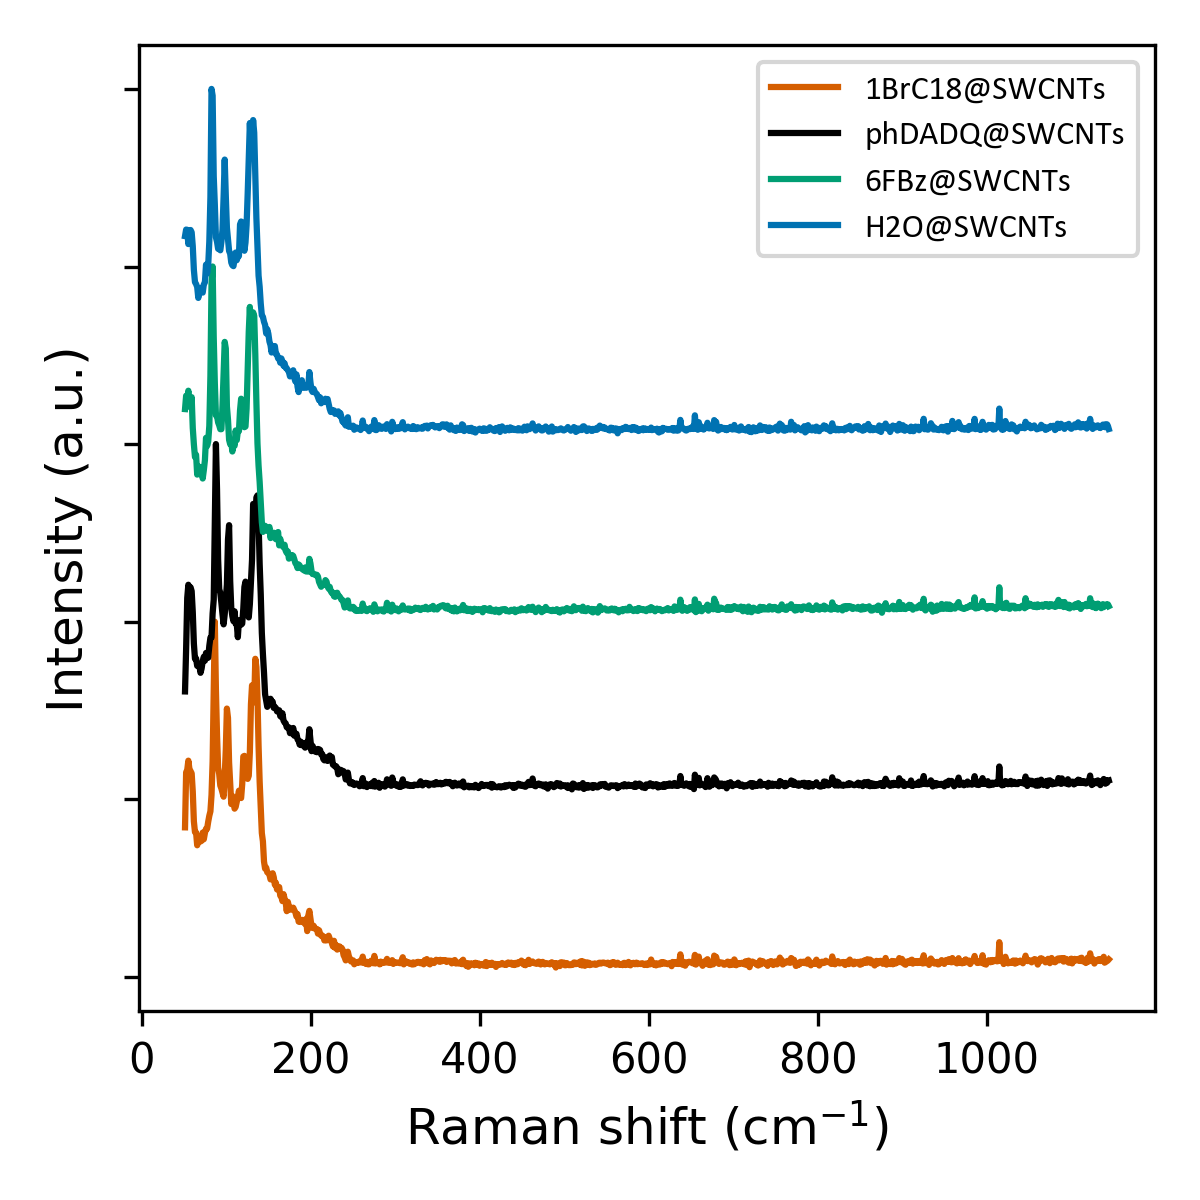

In [2]:
# ============================================================
# 3. SELECT, PIPELINE & PLOTTING (Estilo UV-Vis)
# ============================================================

# Define aquí qué quieres graficar, cómo se llama, su color y su tipo de línea
raman_config = [
    # (Nombre_del_archivo_txt, Nombre_Leyenda, Color, Linestyle)
    ("260807_F007WA_1BrC18@P2_DGUdial_785 nm_1200gr_x10_0_1%_3_120_50_100_sc590.txt", "1BrC18@SWCNTs", "#D55E00", "-"),
    ("260807_F006WA_phDADQ@P2_DGUdial_785 nm_1200gr_x10_0_1%_3_120_50_100_sc590.txt", "phDADQ@SWCNTs", "#000000", "-"),
    ("260807_F005LP_6FBz@P2_DGUdial_785 nm_1200gr_x10_0_1%_3_120_50_100_sc590.txt",   "6FBz@SWCNTs",   "#009E73", "-"),
    ("260807_P2_DGUdial_785 nm_1200gr_x10_0_1%_3_120_50_100_sc590.txt",               "H2O@SWCNTs",    "#0072B2", "-"),
]

# 1. Desempaquetar la configuración
selected_list = []
clean_labels = []
custom_colors = []
custom_linestyles = []

for key, name, col, ls in raman_config:
    selected_list.append(key)
    clean_labels.append(name)
    custom_colors.append(col)
    custom_linestyles.append(ls)

# 2. Filtrar el diccionario original
selected_spectra = {name: raman_spectra[name] for name in selected_list if name in raman_spectra}

# 3. Pipeline de procesamiento
# selected_spectra = TrimSpectra(selected_spectra, xmin=100, xmax=2000)
selected_spectra = NormalizeSpectra(selected_spectra, xmin=0, xmax=10000, mode="M")

# 4. Graficar con todas las opciones nuevas
PlotRaman(
    spectra_dict=selected_spectra, 
    spectra_names=selected_list,
    custom_labels=clean_labels,
    custom_colors=custom_colors,
    custom_linestyles=custom_linestyles,
    offset_step=0.5,                # Controla el apilamiento aquí
    ylabel="Intensity (a.u.)",
    style=poster_style,
    #xmin=100,
    #xmax=3000,
    #vlines=[1590, 2670],            # Líneas verticales idénticas a UV-Vis
    hide_yticks=True,               # Ocultar ticks del eje Y
    legend_ncol=1                   # Columnas en la leyenda
)

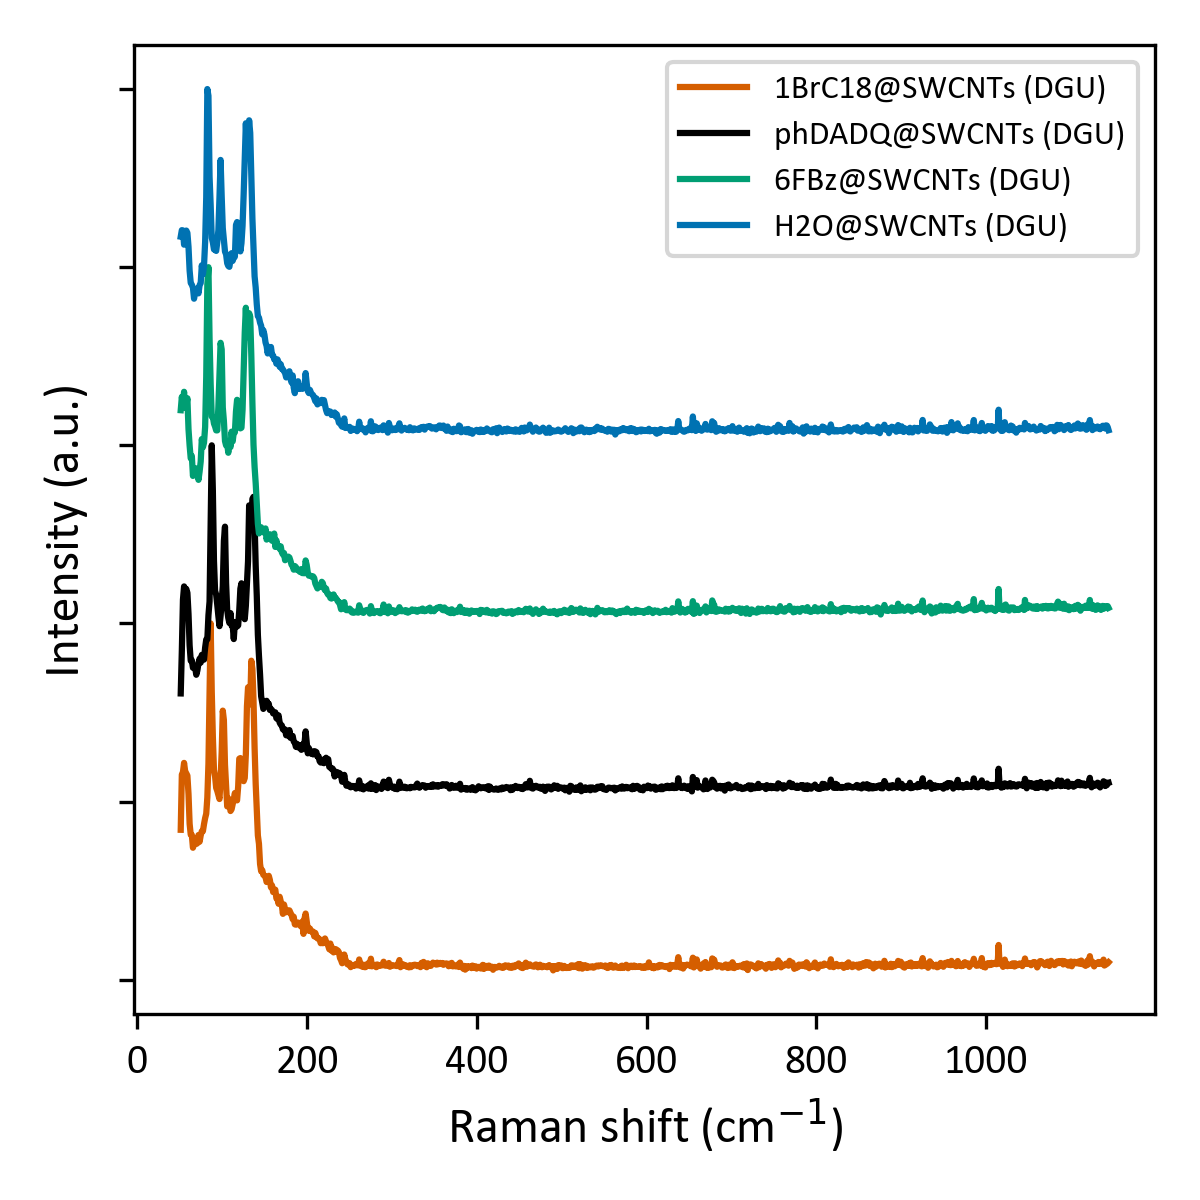

In [3]:
raman_config_785nm_0807 = [
    # (Filename, Legend Name, Color, Linestyle)
    ("260807_F007WA_1BrC18@P2_DGUdial_785 nm_1200gr_x10_0_1%_3_120_50_100_sc590.txt", "1BrC18@SWCNTs (DGU)", "#D55E00", "-"),
    ("260807_F006WA_phDADQ@P2_DGUdial_785 nm_1200gr_x10_0_1%_3_120_50_100_sc590.txt", "phDADQ@SWCNTs (DGU)", "#000000", "-"),
    ("260807_F005LP_6FBz@P2_DGUdial_785 nm_1200gr_x10_0_1%_3_120_50_100_sc590.txt",   "6FBz@SWCNTs (DGU)",   "#009E73", "-"),
    ("260807_P2_DGUdial_785 nm_1200gr_x10_0_1%_3_120_50_100_sc590.txt",               "H2O@SWCNTs (DGU)",    "#0072B2", "-"),
    # ("260807_P2_DGUdialAgain_785 nm_1200gr_x10_0_1%_3_120_50_100_sc590.txt",        "H2O@SWCNTs (Dial Again)", "#56B4E9", "--"),
]

PlotRamanConfig(
    config=raman_config_785nm_0807, 
    spectra_dict=raman_spectra, 
    offset_step=0.5,  # Sube a 1.2 si quieres apilarlos
    hide_yticks=True
)

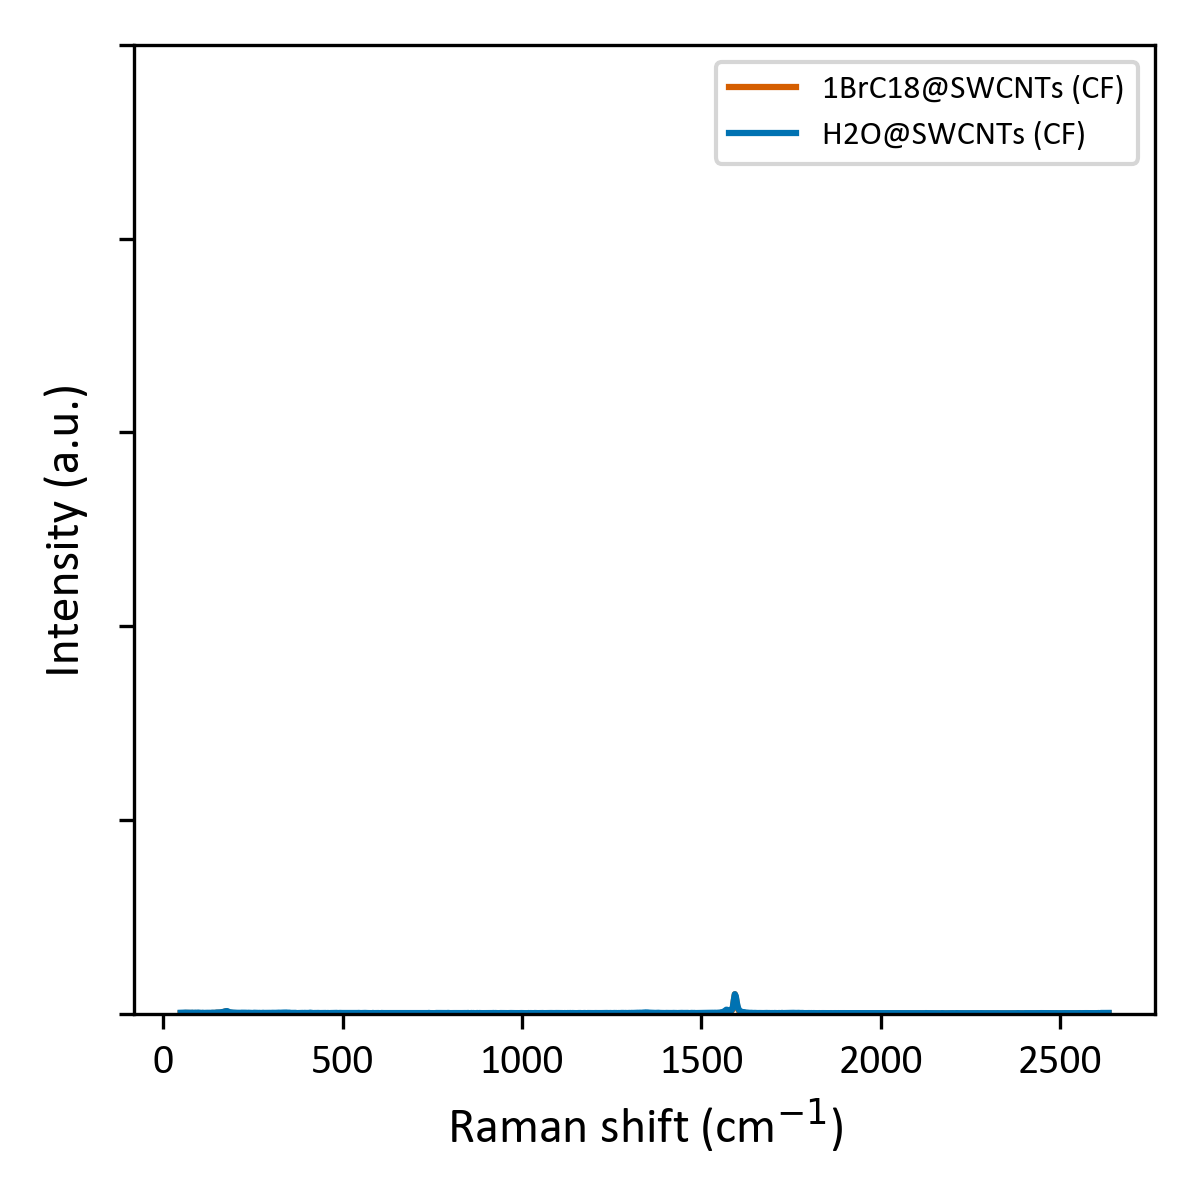

In [4]:
raman_config_532nm_0807 = [
    ("260807_F007_1BrC18@P2_CF_DCG_532 nm_1200gr_x10_0_1%_3_30_50_100_sc1350.txt", "1BrC18@SWCNTs (CF)", "#D55E00", "-"),
    ("260807_P2_CF_DCG_532 nm_1200gr_x10_0_1%_3_30_50_100_sc1350.txt",             "H2O@SWCNTs (CF)",    "#0072B2", "-"),
]

PlotRamanConfig(
    config=raman_config_532nm_0807, 
    spectra_dict=raman_spectra, 
    offset_step=0.0, 
    ymax=50,
    hide_yticks=True
)

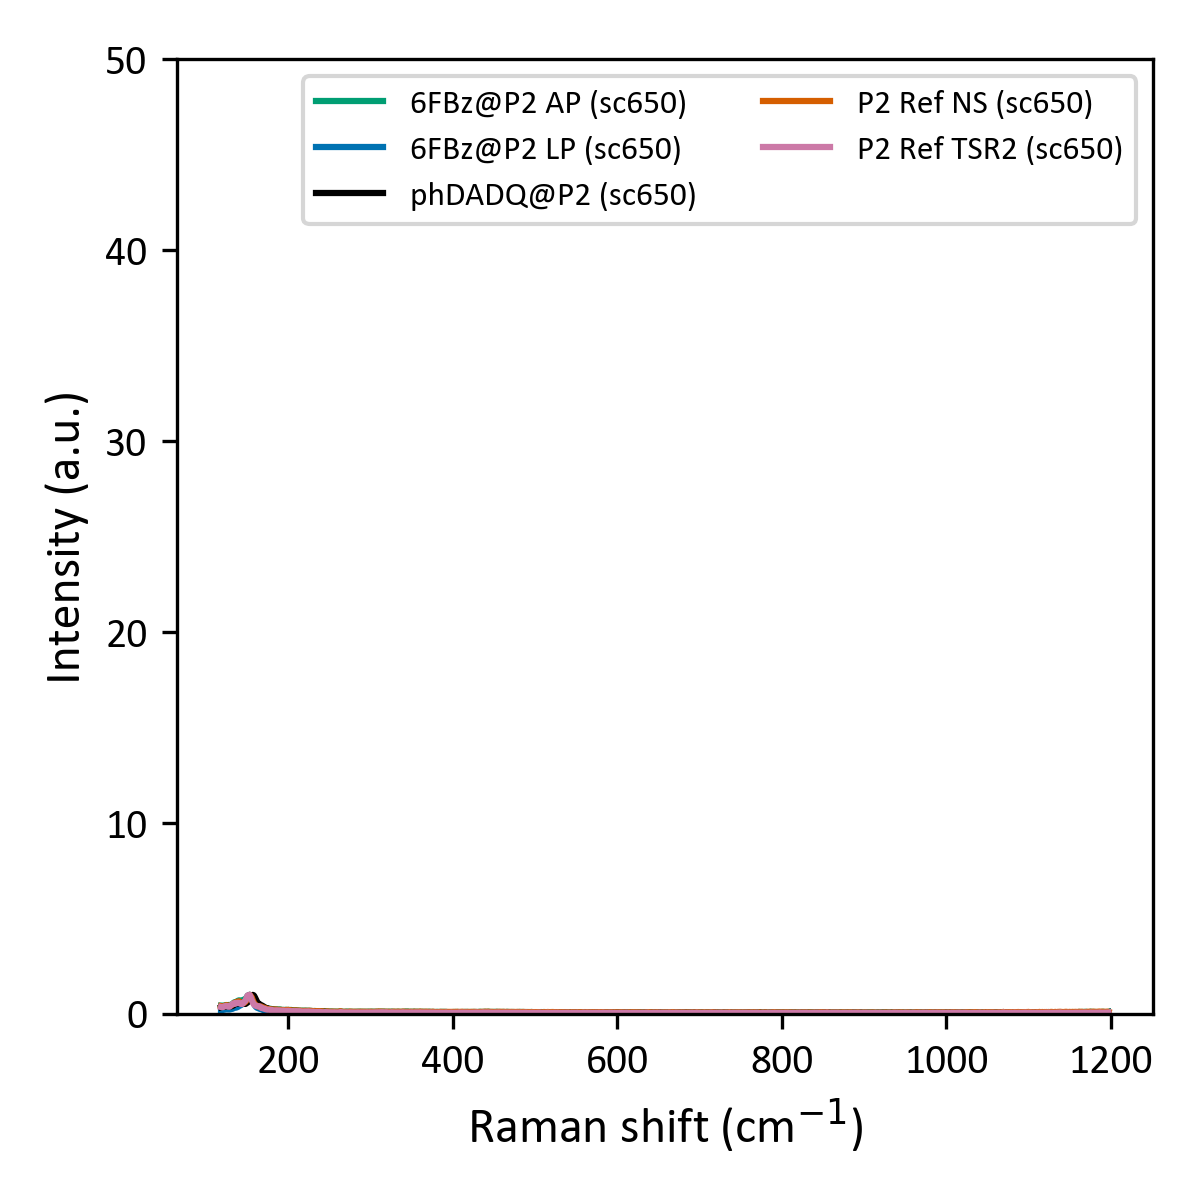

In [5]:
raman_config_785nm_0605 = [
    ("260605_F005AP_6FBz@P2Sol_CF260528_785 nm_1200gr_x10_1%_5_30_50_100_sc650.txt", "6FBz@P2 AP (sc650)", "#009E73", "-"),
    ("260605_F005LP_6FBz@P2Sol_CF260528_785 nm_1200gr_x10_1%_5_30_50_100_sc650.txt", "6FBz@P2 LP (sc650)", "#0072B2", "-"),
    ("260605_F006WA_phDADQ@P2Sol_CF260605_785 nm_1200gr_x10_1%_5_30_50_100_sc650.txt", "phDADQ@P2 (sc650)", "#000000", "-"),
    ("260605_P2_RefSol_NS_CF260529_785 nm_1200gr_x10_1%_5_30_50_100_sc650.txt",      "P2 Ref NS (sc650)",   "#D55E00", "-"),
    ("260605_P2_RefSol_TSR2_CF260224_785 nm_1200gr_x10_1%_5_30_50_100_sc650.txt",    "P2 Ref TSR2 (sc650)", "#CC79A7", "-"),
    # (Descomenta y cambia el color/label de las lecturas sc1250 y sc2000 si las necesitas)
]

PlotRamanConfig(
    config=raman_config_785nm_0605, 
    spectra_dict=raman_spectra, 
    offset_step=0.0, 
    ymax=50,
    legend_ncol=2
)

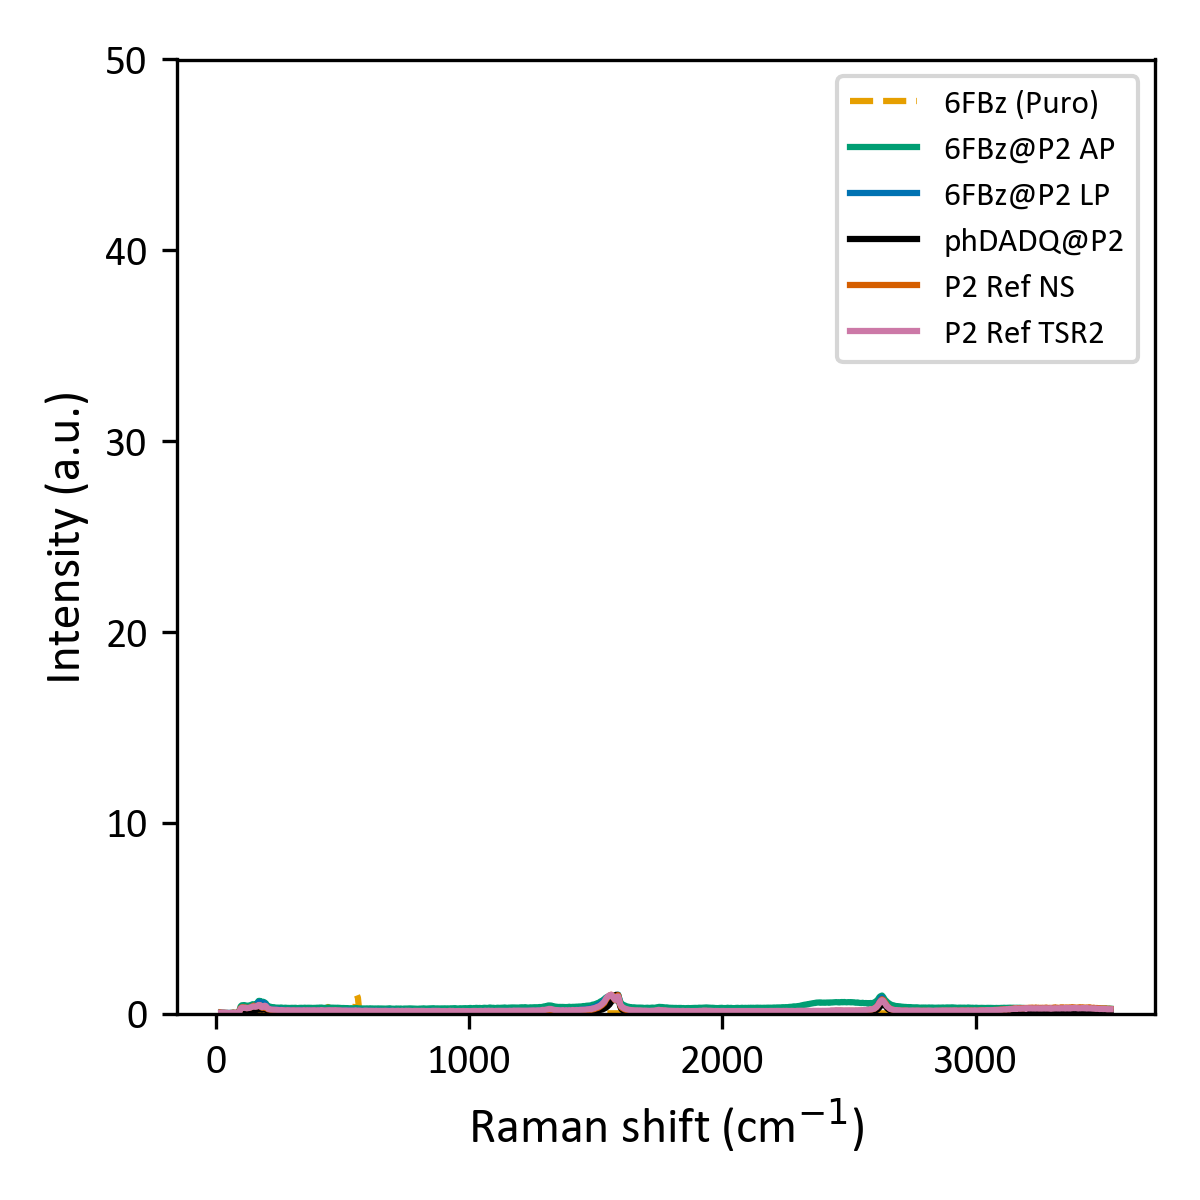

In [6]:
raman_config_638nm_0605 = [
    ("260605_6FBz_638 nm_600gr_x10_1%_3_60_50_100_sc1870.txt",                       "6FBz (Puro)",      "#E69F00", "--"),
    ("260605_F005AP_6FBz@P2Sol_CF260528_638 nm_600gr_x10_1%_3_60_50_100_sc1870.txt", "6FBz@P2 AP",       "#009E73", "-"),
    ("260605_F005LP_6FBz@P2Sol_CF260528_638 nm_600gr_x10_1%_3_60_50_100_sc1870.txt", "6FBz@P2 LP",       "#0072B2", "-"),
    ("260605_F006WA_phDADQ@P2Sol_CF260605_638 nm_600gr_x10_1%_3_60_50_100_sc1870.txt","phDADQ@P2",        "#000000", "-"),
    ("260605_P2_RefSol_NS_CF260529_638 nm_600gr_x10_1%_3_60_50_100_sc1870.txt",      "P2 Ref NS",        "#D55E00", "-"),
    ("260605_P2_RefSol_TSR2_CF260224_638 nm_600gr_x10_1%_3_60_50_100_sc1870.txt",    "P2 Ref TSR2",      "#CC79A7", "-"),
]

PlotRamanConfig(
    config=raman_config_638nm_0605, 
    spectra_dict=raman_spectra, 
    offset_step=0.0, 
    ymax=50
)

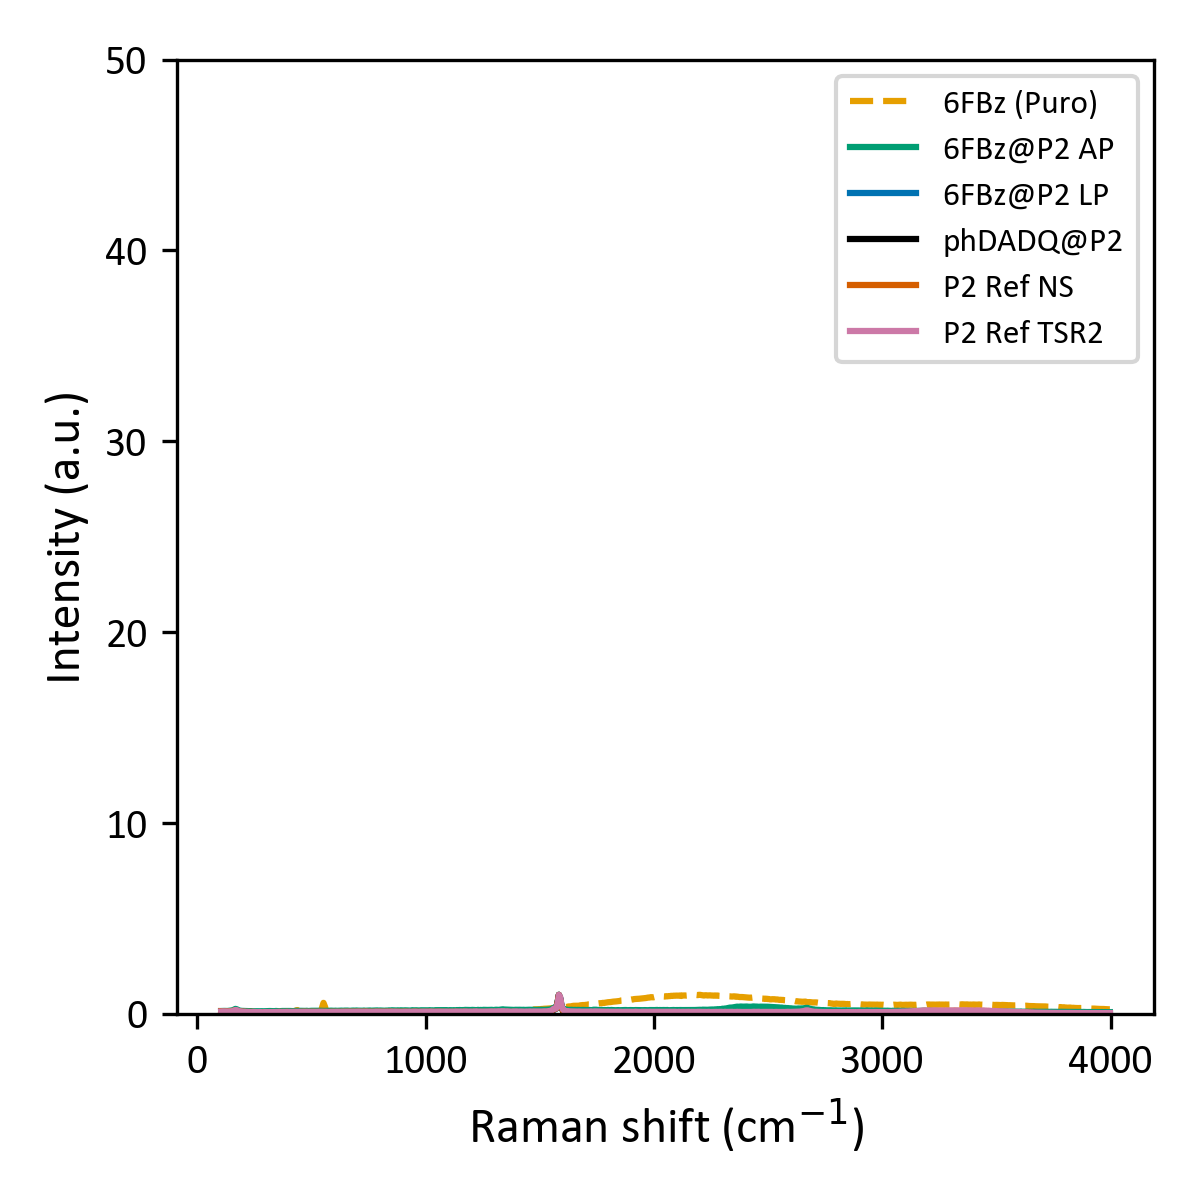

In [7]:
raman_config_532nm_0605 = [
    ("260605_6FBz_532 nm_600gr_x10_1%_3_10_50_100_sc2700.txt",                       "6FBz (Puro)",      "#E69F00", "--"),
    ("260605_F005AP_6FBz@P2Sol_CF260528_532 nm_600gr_x10_1%_3_10_50_100_sc2700.txt", "6FBz@P2 AP",       "#009E73", "-"),
    ("260605_F005LP_6FBz@P2Sol_CF260528_532 nm_600gr_x10_1%_3_10_50_100_sc2700.txt", "6FBz@P2 LP",       "#0072B2", "-"),
    ("260605_F006WA_phDADQ@P2Sol_CF260605_532 nm_600gr_x10_1%_3_10_50_100_sc2700.txt","phDADQ@P2",        "#000000", "-"),
    ("260605_P2_RefSol_NS_CF260529_532 nm_600gr_x10_1%_3_10_50_100_sc2700.txt",      "P2 Ref NS",        "#D55E00", "-"),
    ("260605_P2_RefSol_TSR2_CF260224_532 nm_600gr_x10_1%_3_10_50_100_sc2700.txt",    "P2 Ref TSR2",      "#CC79A7", "-"),
]

PlotRamanConfig(
    config=raman_config_532nm_0605, 
    spectra_dict=raman_spectra, 
    offset_step=0.0, 
    ymax=50
)

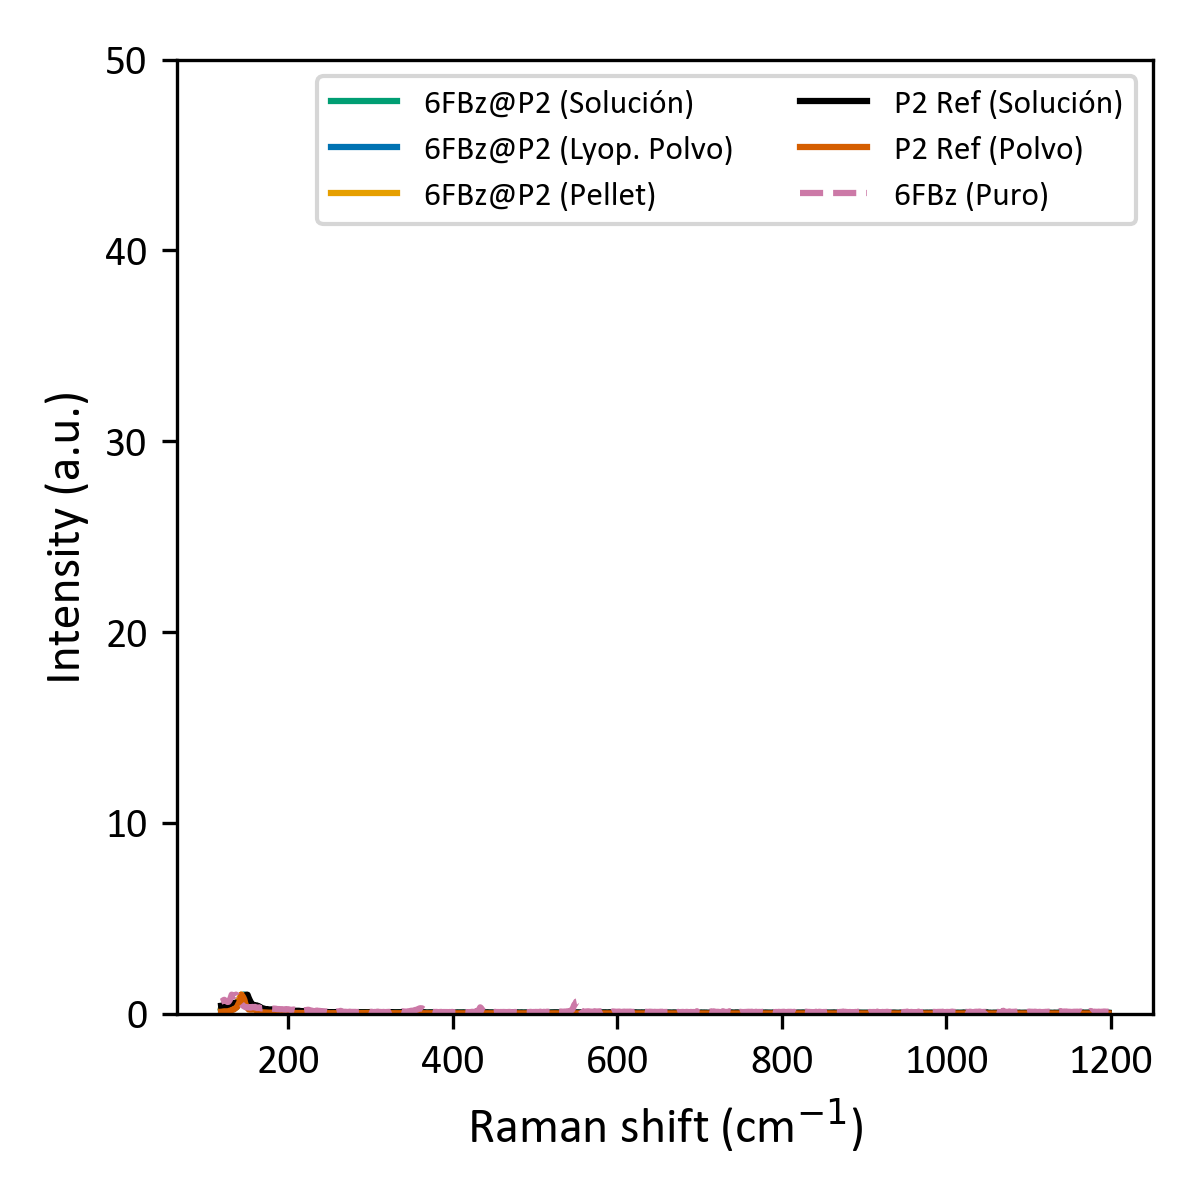

In [8]:
raman_config_785nm_0402 = [
    ("260402_F005_6FBZ@P2Sol_785 nm_1200gr_x10_10%_2_120_50_100.txt",        "6FBz@P2 (Solución)", "#009E73", "-"),
    ("260402_F005_6FBZ@P2LyopPowder_785 nm_1200gr_x10_10%_2_120_50_100.txt", "6FBz@P2 (Lyop. Polvo)", "#0072B2", "-"),
    ("260402_F005_6FBZ@P2Pellet_785 nm_1200gr_x10_10%_2_120_50_100.txt",     "6FBz@P2 (Pellet)",   "#E69F00", "-"),
    ("260402_P2ReferenceSol_785 nm_1200gr_x10_10%_2_120_50_100.txt",         "P2 Ref (Solución)",  "#000000", "-"),
    ("260402_P2ReferencePowd_785 nm_1200gr_x10_10%_2_120_50_100.txt",        "P2 Ref (Polvo)",     "#D55E00", "-"),
    ("260402_Hexafluorobenzene6FBz_785 nm_1200gr_x10_10%_2_120_50_100.txt",  "6FBz (Puro)",        "#CC79A7", "--"),
]

PlotRamanConfig(
    config=raman_config_785nm_0402, 
    spectra_dict=raman_spectra, 
    offset_step=0.0, 
    ymax=50,
    legend_ncol=2
)

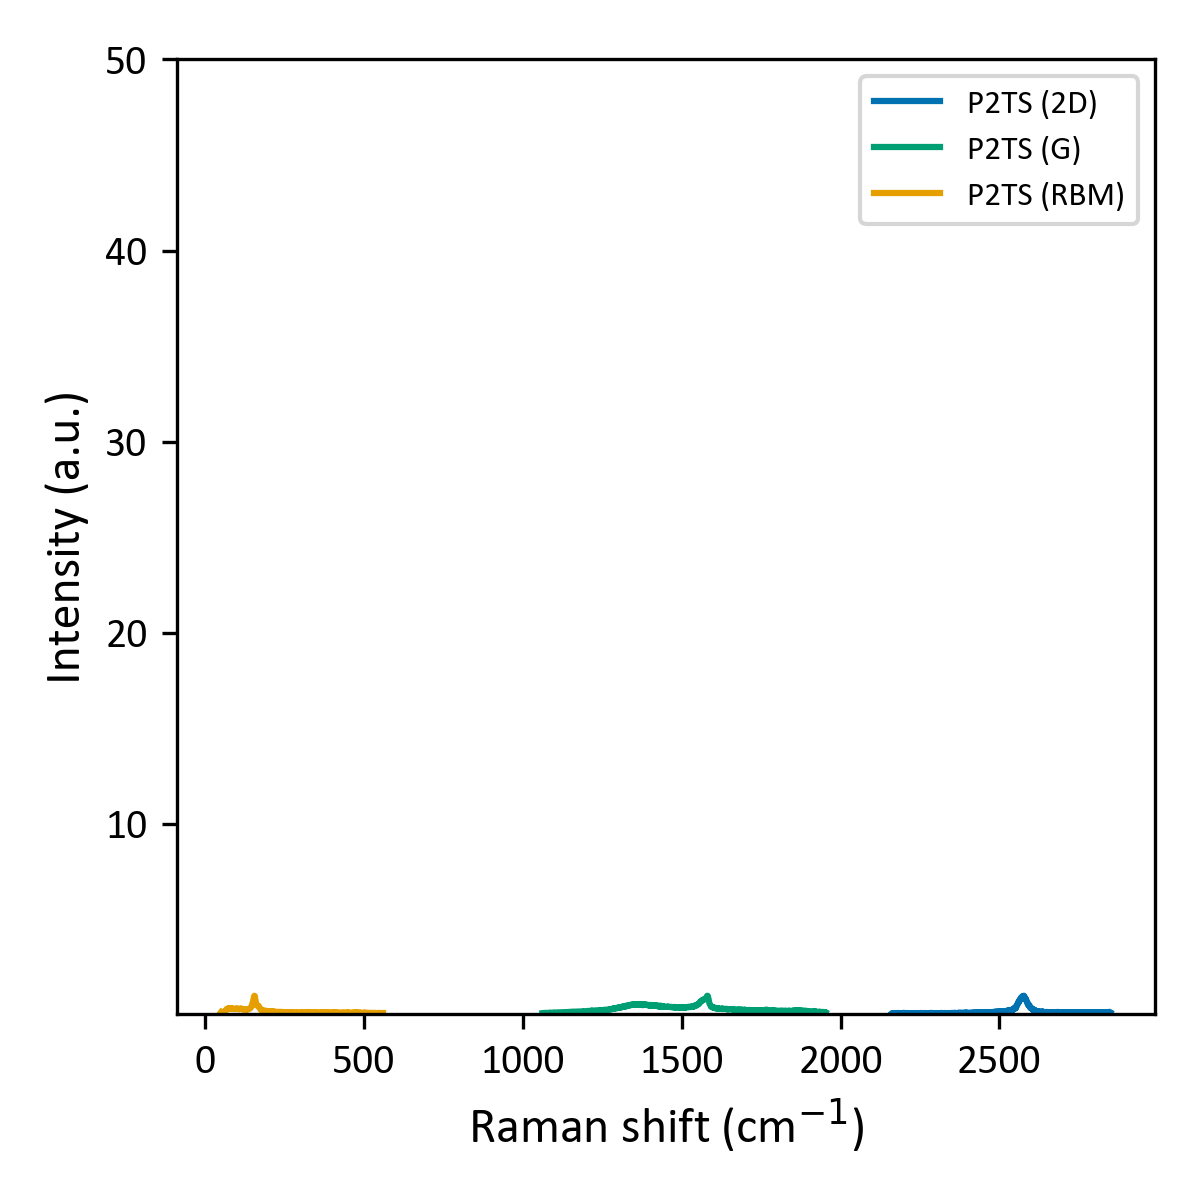

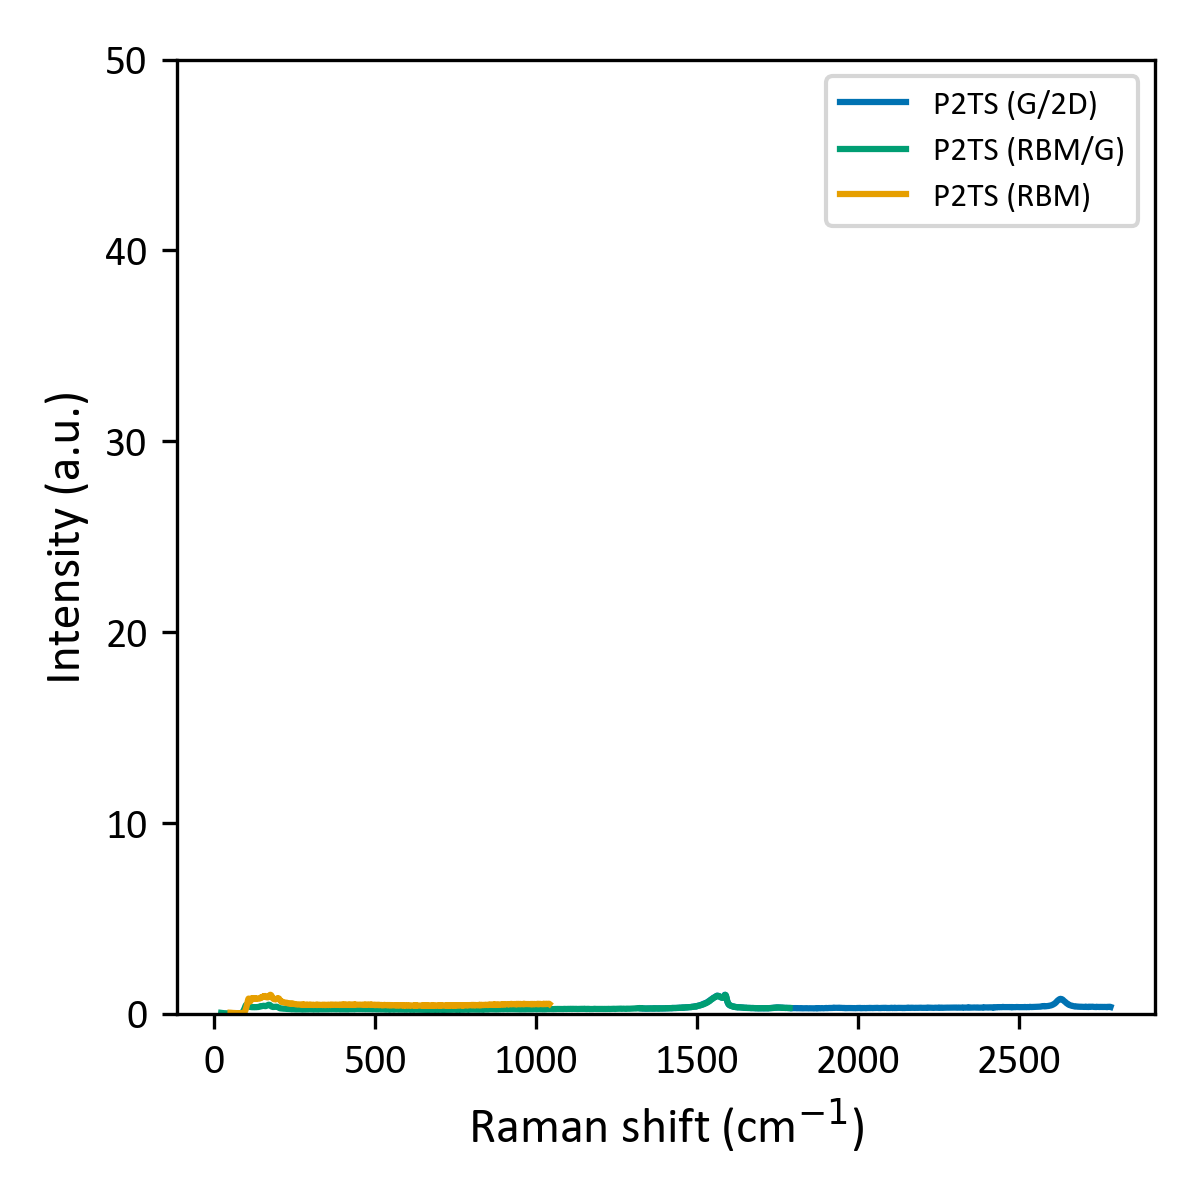

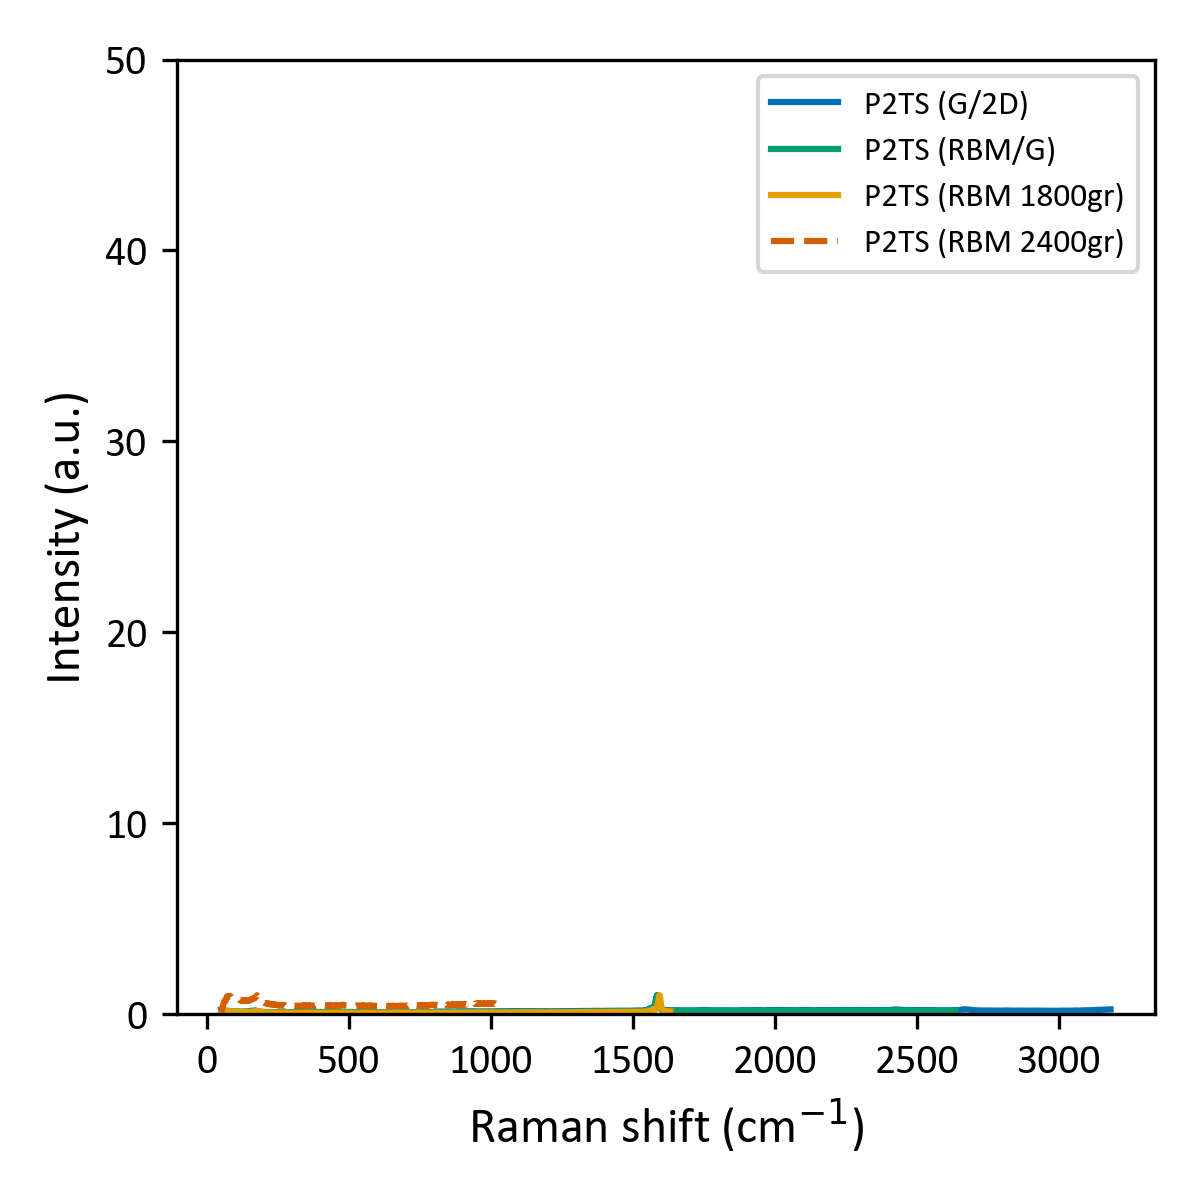

In [9]:
# 785 nm
raman_config_785nm_0218 = [
    ("P2TS_2D_785 nm_1200gr_x10_5_5 s_10%.txt",  "P2TS (2D)",  "#0072B2", "-"),
    ("P2TS_G_785 nm_1200gr_x10_5_5 s_10%.txt",   "P2TS (G)",   "#009E73", "-"),
    ("P2TS_RBM_785 nm_1800gr_x10_5_5 s_100%.txt","P2TS (RBM)", "#E69F00", "-"),
]
PlotRamanConfig(config=raman_config_785nm_0218, spectra_dict=raman_spectra, ymax=50)

# 638 nm
raman_config_638nm_0218 = [
    ("P2TS_G2D_638 nm_1200gr_x10_5_5 s_10%_1.txt", "P2TS (G/2D)", "#0072B2", "-"),
    ("P2TS_RBMG_638 nm_1200gr_x10_5_5 s_10%_2.txt","P2TS (RBM/G)", "#009E73", "-"),
    ("P2TS_RBM_638 nm_1800gr_x10_5_5 s_100%.txt",  "P2TS (RBM)",  "#E69F00", "-"),
]
PlotRamanConfig(config=raman_config_638nm_0218, spectra_dict=raman_spectra, ymax=50)

# 532 nm
raman_config_532nm_0218 = [
    ("P2TS_G2D_532 nm_1200gr_x10_5_5 s_1%.txt",  "P2TS (G/2D)",      "#0072B2", "-"),
    ("P2TS_RBMG_532 nm_1200gr_x10_5_5 s_1%.txt", "P2TS (RBM/G)",     "#009E73", "-"),
    ("P2TS_RBM_532 nm_1800gr_x10_5_5 s_10%.txt", "P2TS (RBM 1800gr)","#E69F00", "-"),
    ("P2TS_RBM_532 nm_2400gr_x10_5_5 s_10%.txt", "P2TS (RBM 2400gr)","#D55E00", "--"),
]
PlotRamanConfig(config=raman_config_532nm_0218, spectra_dict=raman_spectra, ymax=50)